In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [3]:
#Load Dataset
df=pd.read_csv('/Users/tejasmac/ML Projects/Delhi NCR House Price Prediction/data/housing_cleaned.csv')

In [4]:
X=df[["bhk","area_sqft","parking"]]
y=df["price"]

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
from sklearn.ensemble import RandomForestRegressor

rf_model=RandomForestRegressor(n_estimators=100,random_state=42)

In [7]:
rf_model.fit(X_train,y_train)
print("Random Forest Model Trained Successfully!✅")

Random Forest Model Trained Successfully!✅


In [8]:
rf_pred=rf_model.predict(X_test)

In [9]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

#MAE
mae=mean_absolute_error(y_test,rf_pred)
print(f"MAE: ₹{mae/1e7:.2f} Cr")


#MSE
mse=mean_squared_error(y_test,rf_pred)
print(f"MSE: {mse}")

#RMSE
rmse=np.sqrt(mse)
print(f"RMSE: ₹{rmse/1e7:.2f} Cr")

#R2 Score
r2=r2_score(y_test,rf_pred)
print(f"R2 Score: {r2:.2f}")




MAE: ₹1.04 Cr
MSE: 546952718944995.44
RMSE: ₹2.34 Cr
R2 Score: 0.68


In [10]:
# n_estimators Tuning

results=[]
CRORE=1e7

for n in [50, 100, 200, 300, 500]:
    rf_model=RandomForestRegressor(n_estimators=n,
                                   random_state=42)

    rf_model.fit(X_train,y_train)

    current_pred=rf_model.predict(X_test)

    mae=mean_absolute_error(y_test,current_pred)/CRORE
    mse=mean_squared_error(y_test,current_pred)
    rmse=np.sqrt(mse)/CRORE
    r2=r2_score(y_test,current_pred)

    results.append([n,mae,rmse,r2])

results=pd.DataFrame(results,columns=["n_estimators","MAE (₹ CR)", "RMSE (₹ CR)", "R²"])

results=results.round(2)

print(results)

   n_estimators  MAE (₹ CR)  RMSE (₹ CR)    R²
0            50        1.04         2.36  0.68
1           100        1.04         2.34  0.68
2           200        1.04         2.34  0.68
3           300        1.04         2.34  0.68
4           500        1.04         2.33  0.69


In [11]:
#MAX Depth Tuning

results=[]
CRORE=1e7

for depth in [2, 3, 5, 7, 10, 15, None]:
    rf_model=RandomForestRegressor(n_estimators=200,
                                   random_state=42,
                                   max_depth=depth)

    rf_model.fit(X_train,y_train)

    current_pred=rf_model.predict(X_test)

    mae=mean_absolute_error(y_test,current_pred)/CRORE
    mse=mean_squared_error(y_test,current_pred)
    rmse=np.sqrt(mse)/CRORE
    r2=r2_score(y_test,current_pred)
    
    results.append([depth,mae,rmse,r2])
    
results=pd.DataFrame(results,columns=["depth","MAE (₹ CR)", "RMSE (₹ CR)", "R²"])
    
results=results.round(2)
    
print(results)

   depth  MAE (₹ CR)  RMSE (₹ CR)    R²
0    2.0        1.25         2.45  0.65
1    3.0        1.15         2.41  0.66
2    5.0        1.09         2.34  0.68
3    7.0        1.05         2.30  0.69
4   10.0        1.04         2.32  0.69
5   15.0        1.04         2.33  0.69
6    NaN        1.04         2.34  0.68


In [12]:
#Tuned Model

best_rf_model=RandomForestRegressor(random_state=42,
                                    max_depth=7,
                                    n_estimators=200)

In [13]:
best_rf_model.fit(X_train,y_train)
print("Best Random Forest Model trained successfully!✅")

Best Random Forest Model trained successfully!✅


In [14]:
best_rf_pred=best_rf_model.predict(X_test)

In [15]:
#Final Evaluation
mae = mean_absolute_error(y_test, best_rf_pred)
mse = mean_squared_error(y_test, best_rf_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, best_rf_pred)

print(f"MAE : ₹{mae/1e7:.2f} Cr")
print(f"RMSE: ₹{rmse/1e7:.2f} Cr")
print(f"R²  : {r2:.3f}")

MAE : ₹1.05 Cr
RMSE: ₹2.30 Cr
R²  : 0.695


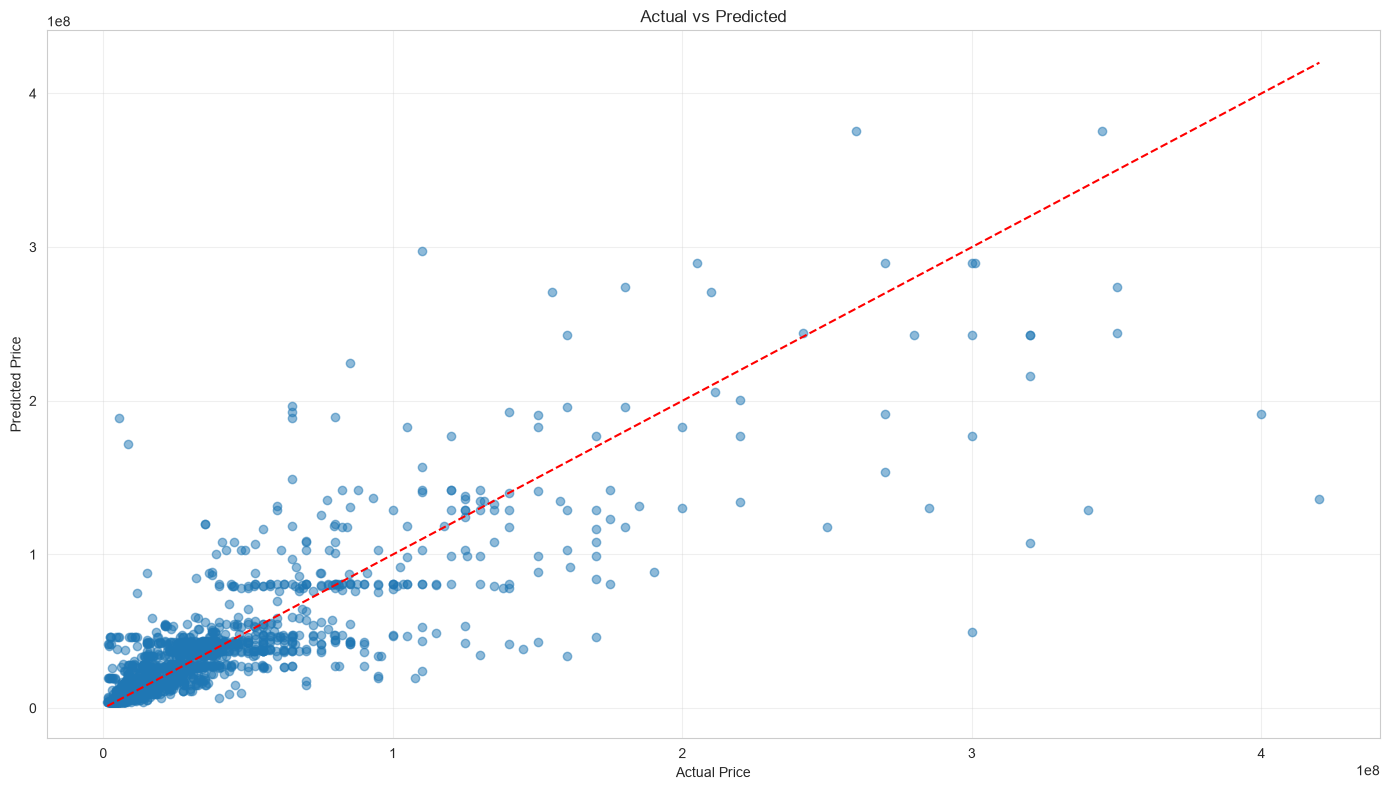

In [16]:
#Actual vs Predicted

plt.figure(figsize=(14,8))

plt.scatter(y_test,best_rf_pred,alpha=0.5)

plt.plot([y_test.min(),y_test.max()],
         [y_test.min(),y_test.max()],
         color="Red",
         linestyle="--")

plt.grid(True,alpha=0.3)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.tight_layout()

plt.savefig("../outputs/plots/actual_vs_predicted_rf.png", dpi=300)


plt.show()

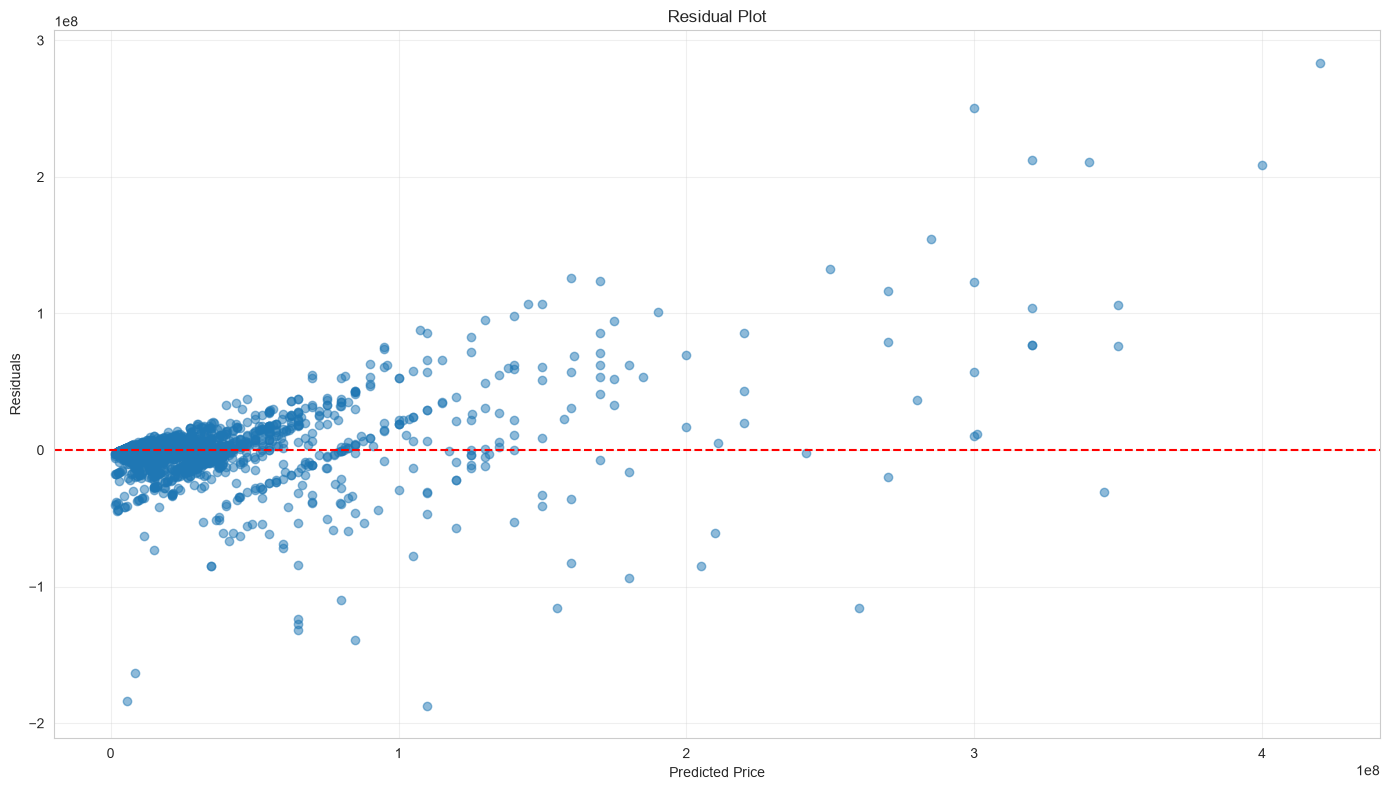

In [17]:
#Residual Plot

plt.figure(figsize=(14,8))
residuals=y_test-best_rf_pred

plt.scatter(y_test,residuals,alpha=0.5)

plt.axhline(y=0,color="Red",linestyle="--")

plt.grid(True,alpha=0.3)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.tight_layout()

plt.savefig("../outputs/plots/residual_plot_rf.png", dpi=300)

plt.show()


In [18]:
import joblib

joblib.dump(best_rf_model, "../models/random_forest_model.pkl")

['../models/random_forest_model.pkl']

In [19]:
predictions_rf=pd.DataFrame({"Actual Price": y_test.values,
                         "Predicted Price": best_rf_pred
                         })

predictions_rf = predictions_rf.round(2)

predictions_rf.to_csv(
    "../outputs/predictions/predictions_rf.csv",
    index=False
)


In [20]:
# User Prediction

area = float(input("Enter Area (sq ft): "))
bhk = int(input("Enter BHK: "))
parking = int(input("Enter Parking: "))

new_house = pd.DataFrame({
     "bhk": [bhk],
    "area_sqft": [area],
    "parking": [parking]
})

prediction = best_rf_model.predict(new_house)

print("----------- Prediction -----------")
print(f"Area      : {area} sq ft")
print(f"BHK       : {bhk}")
print(f"Parking   : {parking}")
print("----------------------------------")
print(f"Estimated Price : ₹{prediction[0]/1e7:.2f}Cr")

----------- Prediction -----------
Area      : 1990.0 sq ft
BHK       : 8
Parking   : 7
----------------------------------
Estimated Price : ₹3.49Cr
